# Notebook 01 — OSM Data Pipeline

**Goal:** Pull the Kigali road network from OpenStreetMap, inspect it, and export the raw graph to `data/kigali_raw.graphml`.

**Produces:** `data/kigali_raw.graphml`

**Phase:** 2

Run all cells top to bottom. Do not proceed to notebook 02 until the validation cell at the bottom passes.

## Cell 1 — Imports and config

In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath('..'))

import osmnx as ox
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

from src.graph import load_raw_graph, RAW_GRAPH_PATH

# OSMnx settings — use cache so repeated runs don't re-hit the API
ox.settings.use_cache = True
ox.settings.log_console = False

print('Environment ready.')
print(f'osmnx version: {ox.__version__}')
print(f'networkx version: {nx.__version__}')

Environment ready.
osmnx version: 2.1.0
networkx version: 3.6.1


## Cell 2 — Pull the graph and time the OSM call

In [2]:
t0 = time.time()
G = load_raw_graph(output_path=RAW_GRAPH_PATH, force_refresh=False)
elapsed = time.time() - t0

print(f'\nTime elapsed: {elapsed:.1f}s')
print(f'Nodes : {len(G.nodes):,}')
print(f'Edges : {len(G.edges):,}')
print(f'Graph type: {type(G).__name__}')

Pulling Kigali road network from OpenStreetMap...
Saved to data/kigali_raw.graphml — 19,022 nodes, 50,411 edges

Time elapsed: 100.9s
Nodes : 19,022
Edges : 50,411
Graph type: MultiDiGraph


## Cell 3 — Basic graph statistics

In [3]:
# Connected components
undirected = G.to_undirected()
components = list(nx.connected_components(undirected))
print(f'Connected components  : {len(components)}')
print(f'Largest component     : {max(len(c) for c in components):,} nodes')
print(f'Smallest component    : {min(len(c) for c in components):,} nodes')

# Degree stats
degrees = [d for _, d in G.degree()]
print(f'\nDegree stats (directed):')
print(f'  Mean   : {sum(degrees)/len(degrees):.2f}')
print(f'  Max    : {max(degrees)}')
print(f'  Min    : {min(degrees)}')

# CRS
crs = G.graph.get('crs', 'not set')
print(f'\nCRS: {crs}')

Connected components  : 1
Largest component     : 19,022 nodes
Smallest component    : 19,022 nodes

Degree stats (directed):
  Mean   : 5.30
  Max    : 12
  Min    : 1

CRS: epsg:4326


## Cell 4 — Plot the raw graph

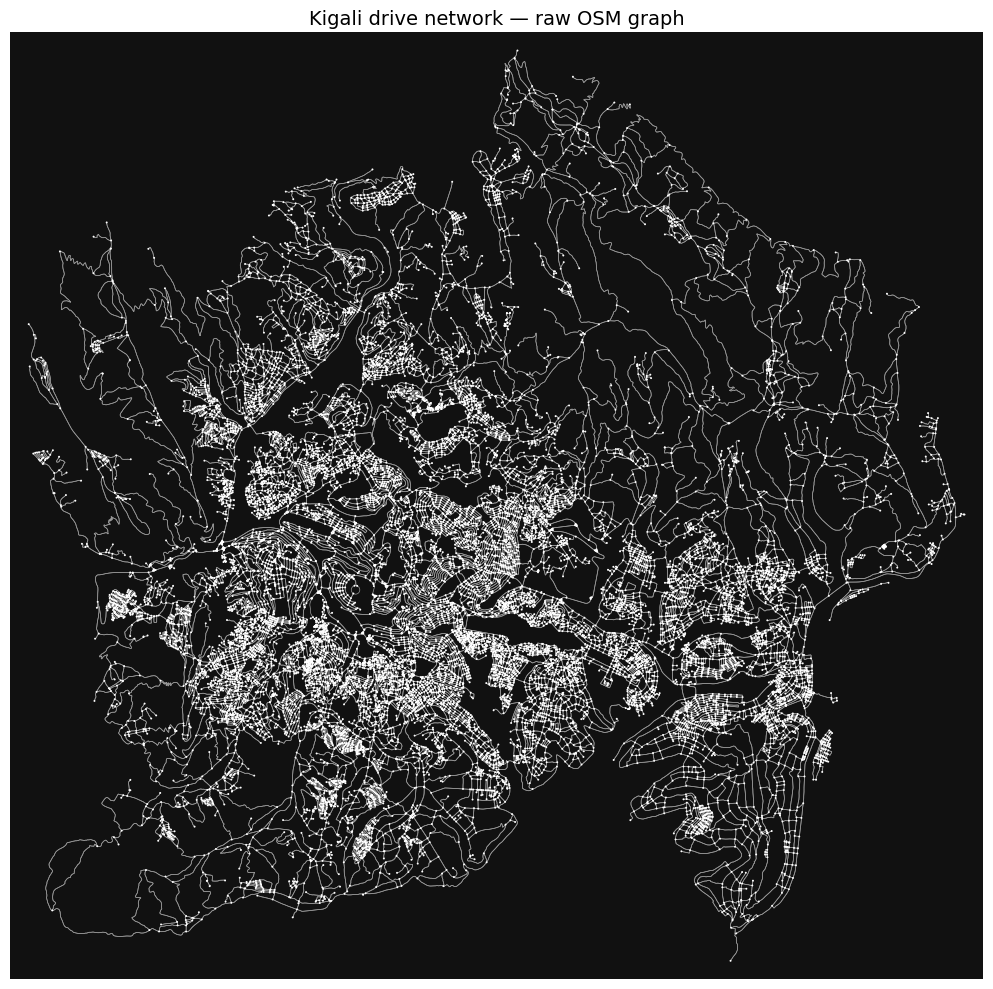


Verify: major roads visible, network covers greater Kigali area.


In [4]:
# Quick visual check — verify this looks like Kigali's road network
fig, ax = ox.plot_graph(
    G,
    figsize=(12, 10),
    node_size=2,
    edge_linewidth=0.5,
    show=False,
    close=False,
)
ax.set_title('Kigali drive network — raw OSM graph', fontsize=14)
plt.tight_layout()
plt.show()
print('\nVerify: major roads visible, network covers greater Kigali area.')

## Cell 5 — Inspect edge attributes

In [5]:
# Collect all unique edge attribute keys
all_keys = set()
for u, v, data in G.edges(data=True):
    all_keys.update(data.keys())

print('Edge attributes present in graph:')
for k in sorted(all_keys):
    print(f'  {k}')

print('\nRequired attributes check:')
for required in ['highway', 'length', 'name']:
    present = required in all_keys
    print(f'  {required}: {"present" if present else "MISSING"}')

# Sample a single edge to see what values look like
sample_u, sample_v, sample_data = next(iter(G.edges(data=True)))
print(f'\nSample edge ({sample_u} → {sample_v}):')
for k, v in sample_data.items():
    print(f'  {k}: {v}')

Edge attributes present in graph:
  access
  bridge
  geometry
  highway
  junction
  lanes
  length
  maxspeed
  name
  oneway
  osmid
  ref
  reversed
  width

Required attributes check:
  highway: present
  length: present
  name: present

Sample edge (279244409 → 6302690489):
  osmid: 25796180
  highway: secondary
  lanes: 2
  maxspeed: 40
  name: KG 4 Avenue
  oneway: True
  reversed: False
  length: 293.9296837484787
  geometry: LINESTRING (30.0866001 -1.9538695, 30.0865031 -1.9537688, 30.0863997 -1.953629, 30.0863483 -1.9535425, 30.0862789 -1.9533919, 30.0862353 -1.9532159, 30.0862058 -1.9530691, 30.0862111 -1.9528855, 30.0862091 -1.9526952, 30.0861917 -1.9526013, 30.0861461 -1.9524258, 30.0860562 -1.9522214, 30.085955 -1.9520538, 30.0859167 -1.9520057, 30.0858376 -1.9519064, 30.0857323 -1.9517958, 30.0855017 -1.9515718)


## Cell 6 — Surface tag coverage

In [6]:
total_edges = len(G.edges())
edges_with_surface = sum(1 for _, _, d in G.edges(data=True) if 'surface' in d)
edges_with_highway = sum(1 for _, _, d in G.edges(data=True) if 'highway' in d)
edges_with_length  = sum(1 for _, _, d in G.edges(data=True) if 'length' in d)

print(f'Total edges               : {total_edges:,}')
print(f'Edges with highway tag    : {edges_with_highway:,} ({edges_with_highway/total_edges*100:.1f}%)')
print(f'Edges with length attr    : {edges_with_length:,} ({edges_with_length/total_edges*100:.1f}%)')
print(f'Edges with surface tag    : {edges_with_surface:,} ({edges_with_surface/total_edges*100:.1f}%)')

# Breakdown of highway types
from collections import Counter
highway_counts = Counter()
for _, _, d in G.edges(data=True):
    hw = d.get('highway', 'unknown')
    if isinstance(hw, list):
        hw = hw[0]
    highway_counts[hw] += 1

print('\nHighway type breakdown:')
for hw_type, count in highway_counts.most_common():
    print(f'  {hw_type:<20} {count:>6,}  ({count/total_edges*100:.1f}%)')

Total edges               : 50,411
Edges with highway tag    : 50,411 (100.0%)
Edges with length attr    : 50,411 (100.0%)
Edges with surface tag    : 0 (0.0%)

Highway type breakdown:
  residential          34,124  (67.7%)
  unclassified          9,306  (18.5%)
  secondary             4,120  (8.2%)
  tertiary              1,945  (3.9%)
  trunk                   636  (1.3%)
  primary                 131  (0.3%)
  trunk_link               72  (0.1%)
  secondary_link           35  (0.1%)
  living_street            18  (0.0%)
  primary_link             13  (0.0%)
  tertiary_link            11  (0.0%)


## Cell 7 — Confirm file on disk

In [7]:
file_size_mb = os.path.getsize(RAW_GRAPH_PATH) / (1024 * 1024)
print(f'File: {RAW_GRAPH_PATH}')
print(f'Size: {file_size_mb:.1f} MB')
print(f'Exists: {os.path.exists(RAW_GRAPH_PATH)}')

File: data/kigali_raw.graphml
Size: 25.5 MB
Exists: True


## Cell 8 — Reload from disk and verify round-trip

In [8]:
print('Reloading graph from disk...')
G2 = load_raw_graph(output_path=RAW_GRAPH_PATH, force_refresh=False)

nodes_match = len(G.nodes) == len(G2.nodes)
edges_match = len(G.edges) == len(G2.edges)

print(f'\nRound-trip validation:')
print(f'  Node count matches: {nodes_match}  ({len(G.nodes):,} == {len(G2.nodes):,})')
print(f'  Edge count matches: {edges_match}  ({len(G.edges):,} == {len(G2.edges):,})')

# Verify length attribute survived the round-trip
sample_edge_orig = next(iter(G.edges(data=True)))
u, v = sample_edge_orig[0], sample_edge_orig[1]
len_orig = G[u][v][0].get('length')
len_reload = G2[u][v][0].get('length') if G2.has_edge(u, v) else None
print(f'  Sample edge length survived: {len_orig} → {len_reload}')

assert nodes_match, 'Node count mismatch after reload!'
assert edges_match, 'Edge count mismatch after reload!'
print('\n✓ Phase 2 validation passed. Proceed to notebook 02.')

Reloading graph from disk...
Loading raw graph from disk: data/kigali_raw.graphml
Loaded — 19,022 nodes, 50,411 edges

Round-trip validation:
  Node count matches: True  (19,022 == 19,022)
  Edge count matches: True  (50,411 == 50,411)
  Sample edge length survived: 293.9296837484787 → 293.9296837484787

✓ Phase 2 validation passed. Proceed to notebook 02.
